# Analysis 4 — Finding Groups in Flooring Spectra (Clustering)

*A tutorial walk-through. No prior machine-learning background assumed.*

## What is this notebook about?

We scanned a bunch of flooring samples — some **vinyl plank (LVP)** and some **real
hardwood** — with a **near-infrared (NIR) spectrometer**. That instrument shines invisible
infrared light at a sample and measures how much is absorbed at each wavelength. Different
materials absorb differently, so every scan is essentially a "chemical fingerprint": a curve
of 249 numbers (one per wavelength from 1454–2446 nm).

In earlier notebooks we did **supervised** learning — we *told* the model which scan was
vinyl and which was oak, and it learned to tell them apart.

This notebook does the opposite: **unsupervised clustering**. We hide all the labels and ask
the computer:

> "Here are 134 fingerprints. Without being told what anything is, can you sort them into
> natural groups based purely on how similar they look?"

Then we *un-hide* the labels and check: did the groups the computer found actually line up
with vinyl-vs-hardwood, or with the individual wood species? This tells us how much structure
is "obvious" in the data versus how much really needs labelled training.

## The plan

| Step | Question we ask |
|------|-----------------|
| Diagnostics | How many natural groups are there, really? |
| **k = 2** | Do two groups recover *vinyl vs hardwood*? |
| **k = 9** | Do nine groups recover all *nine product classes*? |
| **k = 6** | Among the wood scans, do six groups recover the *species*? |
| Hierarchical | Do we get the same answer with a "family tree" method, and what does the tree look like? |

**A yardstick to compare against.** A colleague (Chris) ran the *supervised* versions of these
tasks. Those scores are the bar to keep in mind:

- Telling vinyl from hardwood is essentially trivial (one PCA axis already explains 93% of all variation).
- Supervised models hit ~96% accuracy on the 9 classes and ~95% on wood species.

Clustering has its hands tied behind its back (no labels), so matching those numbers would be impressive.

In [1]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             adjusted_rand_score, homogeneity_score,
                             completeness_score, v_measure_score, confusion_matrix)

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11
})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load the data and recover the labels

Each scan in the spreadsheet comes with a free-text description like
`"vinyl, BrandX, wl 12, ..."` or `"lumber, oak"`. The `parse_desc()` helper reads those
strings and pulls out the structured facts we need: **is it vinyl or wood?**, **what wear-layer
thickness?** (vinyl only), **what species?** (wood only).

Remember: we will **not** feed these labels into the clustering. We only keep them on the side
so that *afterwards* we can grade how well the unsupervised groups match reality.

In [2]:
FILE = '2026-05-21_22-59_Method Dev_wavelength_range_1450-2450.xlsx'
spec_df = pd.read_excel(FILE, sheet_name=1)
meta_df = pd.read_excel(FILE, sheet_name=0)

wavelengths = spec_df['Wavelength (nm)'].values
spec_cols   = [c for c in spec_df.columns if c != 'Wavelength (nm)']
meta_dict   = dict(zip(meta_df['Spectrum ID'], meta_df['Measurement Description']))

def parse_desc(d):
    """Parse a trinamiX Measurement Description into a structured dict."""
    d = d.strip()
    if d.lower().startswith('water') or d.lower().startswith('test'):
        return None
    parts = [p.strip() for p in d.split(',')]
    if parts[0].lower() == 'vinyl':
        wl = None; price = None; color_parts = []
        brand = parts[1].strip() if len(parts) > 1 else 'unknown'
        for p in parts[2:]:
            p = p.strip()
            if p.lower().startswith('wl '):
                try:   wl = float(p.split()[1])
                except: pass
            else:
                try:   price = float(p)
                except: color_parts.append(p)
        return {'type': 'LVP', 'brand': brand, 'wear_layer': wl,
                'price': price, 'color': ' '.join(color_parts), 'desc': d}
    elif parts[0].lower() == 'lumber':
        species = parts[1].strip() if len(parts) > 1 else 'unknown'
        return {'type': 'Hardwood', 'species': species.strip(), 'desc': d}
    return None

rows = []
for sid in spec_cols:
    desc = meta_dict.get(sid)
    if not desc: continue
    parsed = parse_desc(str(desc))
    if not parsed: continue
    rows.append({'id': sid, **parsed, 'spectrum': spec_df[sid].values})

df = pd.DataFrame([{k: v for k, v in r.items() if k != 'spectrum'} for r in rows])
spectra = np.array([r['spectrum'] for r in rows])
print(f'Usable scans: {len(rows)}  |  wavelengths: {spectra.shape[1]}  '
      f'({wavelengths.min():.0f}-{wavelengths.max():.0f} nm)')
df['type'].value_counts()

Usable scans: 134  |  wavelengths: 249  (1454-2446 nm)


type
LVP         90
Hardwood    44
Name: count, dtype: int64

## 2. Clean up the spectra (preprocessing)

Raw NIR scans have two nuisances that have nothing to do with the material:

1. **Overall brightness drifts** — hold the probe slightly closer or further and *every*
   reading scales up or down, even for the same sample.
2. **Gentle baseline tilt** — broad, slowly-varying slopes across the spectrum.

Two standard fixes remove these so that only the *true chemical differences* remain:

- **SNV (Standard Normal Variate):** for each scan, subtract its own average and divide by its
  own spread. This puts every scan on the same footing — like grading everyone on a curve so a
  "loud" scan and a "quiet" scan become comparable.
- **Savitzky–Golay 1st derivative:** instead of the absorbance itself, use its *rate of change*
  along the wavelength axis. Derivatives ignore flat offsets and emphasise where peaks rise and
  fall — the sharp, informative features. (It also smooths a little so we don't amplify noise.)

After this, `X_all` is our cleaned 134 × 249 matrix — the input to everything below.

In [3]:
def snv(X):
    return (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

def sg1(X, window=11, polyorder=2):
    return savgol_filter(X, window_length=window, polyorder=polyorder, deriv=1, axis=1)

X_all = sg1(snv(spectra))
print('Preprocessed feature matrix:', X_all.shape)

Preprocessed feature matrix: (134, 249)


## 3. Set aside the answer keys

Here we build three "answer keys" we'll grade against later:

- **`y_binary`** — vinyl vs hardwood (2 possible answers)
- **`y_9`** — the full product class, e.g. `LVP_12` or `HW_oak` (9 possible answers)
- **`y_wood`** — just the species, for the wood-only scans (6 possible answers)

Again — these are graded *against*, never *learned from*.

In [4]:
y_binary = df['type'].values

def class9(r):
    return f"LVP_{int(r['wear_layer'])}" if r['type'] == 'LVP' else f"HW_{r['species']}"
y_9 = df.apply(class9, axis=1).values

wood_mask = (df['type'] == 'Hardwood').values
X_wood = X_all[wood_mask]
y_wood = df.loc[wood_mask, 'species'].values

print('Binary :', dict(pd.Series(y_binary).value_counts()))
print('9-class:', dict(pd.Series(y_9).value_counts()))
print('Wood   :', dict(pd.Series(y_wood).value_counts()))

Binary : {'LVP': np.int64(90), 'Hardwood': np.int64(44)}
9-class: {'LVP_6': np.int64(33), 'LVP_12': np.int64(30), 'LVP_22': np.int64(27), 'HW_pine': np.int64(11), 'HW_fir': np.int64(10), 'HW_mahogany': np.int64(6), 'HW_oak': np.int64(6), 'HW_poplar': np.int64(6), 'HW_particle board': np.int64(5)}
Wood   : {'pine': np.int64(11), 'fir': np.int64(10), 'mahogany': np.int64(6), 'oak': np.int64(6), 'poplar': np.int64(6), 'particle board': np.int64(5)}


### A bit more prep: putting wavelengths on equal footing, and a 2-D map

**Why scale?** Clustering measures how "far apart" two scans are by adding up differences across
all 249 wavelengths. If one wavelength happens to have much bigger numbers than the others, it
would dominate that distance and drown out the rest. `StandardScaler` rescales every wavelength
to a comparable range so each gets an equal vote.

**Why PCA?** Our data lives in 249 dimensions — impossible to picture. **PCA (Principal Component
Analysis)** squashes it down to 2 dimensions for plotting, keeping as much of the spread as
possible. Think of it as the single most informative "photograph" of a 249-dimensional cloud.
We use it *only to draw pictures*; the clustering itself still uses all 249 wavelengths.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print('PCA variance explained (PC1, PC2):',
      np.round(pca.explained_variance_ratio_[:2] * 100, 2), '%')

PCA variance explained (PC1, PC2): [75.77 12.75] %


## 4. How many groups are there, really?

Before forcing the data into 2 or 9 groups, we ask the data itself: *how many natural groups do
you actually contain?* We try every number of groups from 2 to 15 and score each with three
"how clean are these groups?" measures. None needs labels — they only look at the shape of the
clusters.

**The three measures, in plain terms:**

- **Inertia** — how tightly packed each group is (total distance from points to their group's
  centre). Always drops as you add more groups, so we don't pick the minimum; instead we look for
  the **"elbow"** — the point where adding another group stops buying much extra tightness.
- **Silhouette score** (−1 to 1) — for each scan, "how much closer am I to my own group than to
  the nearest *other* group?" **Higher is better.** Around 0.7+ means clean, well-separated groups.
- **Davies–Bouldin index** — roughly, average group size ÷ distance between groups. **Lower is
  better** (compact groups that sit far apart).

If all three point to the same number, that's a strong signal for the real group count.

In [6]:
k_range = range(2, 16)
inertias, silhouettes, db_scores = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

diag = pd.DataFrame({'k': list(k_range), 'inertia': inertias,
                     'silhouette': silhouettes, 'davies_bouldin': db_scores})
best_sil_k = diag.loc[diag['silhouette'].idxmax(), 'k']
best_db_k  = diag.loc[diag['davies_bouldin'].idxmin(), 'k']
print(f'Best k by silhouette : {int(best_sil_k)}  (={diag["silhouette"].max():.3f})')
print(f'Best k by Davies-Bouldin: {int(best_db_k)}  (={diag["davies_bouldin"].min():.3f})')
diag.round(3)

Best k by silhouette : 2  (=0.687)
Best k by Davies-Bouldin: 2  (=0.508)


,k,inertia,silhouette,davies_bouldin
0,2,8366.066,0.687,0.508
1,3,5636.945,0.534,0.660
2,4,3057.420,0.541,0.625
3,5,2459.731,0.503,0.730
4,6,2097.134,0.427,0.905
5,7,1844.334,0.451,0.833
6,8,1638.768,0.423,0.947
7,9,1504.663,0.417,1.047
8,10,1347.801,0.451,0.872
9,11,1226.234,0.453,0.788


*The plot below shows all three diagnostics at once. Watch for the elbow in the first panel and the peak/trough (marked by the dashed line) in the other two.*

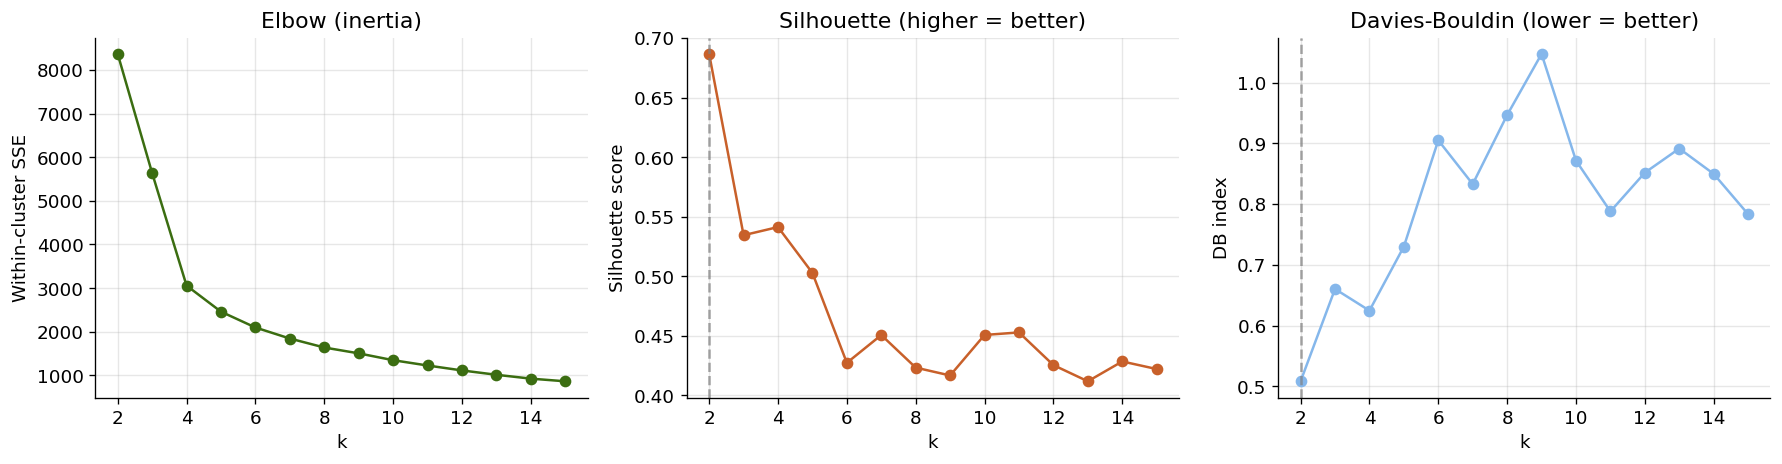

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(diag['k'], diag['inertia'], 'o-', color='#3b6d11')
ax[0].set(title='Elbow (inertia)', xlabel='k', ylabel='Within-cluster SSE')
ax[1].plot(diag['k'], diag['silhouette'], 'o-', color='#c8602a')
ax[1].axvline(best_sil_k, ls='--', c='grey', alpha=.7)
ax[1].set(title='Silhouette (higher = better)', xlabel='k', ylabel='Silhouette score')
ax[2].plot(diag['k'], diag['davies_bouldin'], 'o-', color='#85b7eb')
ax[2].axvline(best_db_k, ls='--', c='grey', alpha=.7)
ax[2].set(title='Davies-Bouldin (lower = better)', xlabel='k', ylabel='DB index')
plt.tight_layout()
plt.savefig('clustering_elbow.png', bbox_inches='tight', dpi=120)
plt.show()

## 5. A scorecard for comparing clusters to the answer key

The computer labels its groups `0, 1, 2, …` in an arbitrary order — its "group 0" might be our
hardwood, or might be our vinyl. So we can't just check equality. Instead we use measures that
don't care about the naming:

- **Purity** — assign each cluster to whatever true label is most common inside it, then ask
  "what fraction of all scans were thereby labelled correctly?" 1.0 = perfect.
- **ARI (Adjusted Rand Index)** — do pairs of scans that belong together get grouped together?
  1.0 = identical to truth, 0 = no better than random guessing.
- **Homogeneity** — "does each cluster contain only one true class?" (no mixing *in*).
- **Completeness** — "does each true class stay together in one cluster?" (no splitting *out*).
- **V-measure** — the balance of homogeneity and completeness in a single number.

The helper below computes all of these plus a cluster-vs-label table.

In [8]:
def cluster_scores(y_true, y_pred):
    cm = pd.crosstab(pd.Series(y_pred, name='cluster'),
                     pd.Series(y_true, name='label'))
    purity = cm.max(axis=1).sum() / cm.values.sum()
    return {
        'ARI':          adjusted_rand_score(y_true, y_pred),
        'homogeneity':  homogeneity_score(y_true, y_pred),
        'completeness': completeness_score(y_true, y_pred),
        'v_measure':    v_measure_score(y_true, y_pred),
        'purity':       purity,
    }, cm

## 6. Experiment A — ask for 2 groups (expecting vinyl vs hardwood)

This is the easy case. Vinyl is plastic (PVC); wood is, well, wood — chemically very different.
If clustering is working at all, two groups should split almost perfectly along that line.

**What to look for below:** a purity and ARI near **1.0**, and a table where each cluster is
essentially all-vinyl or all-hardwood. The scatter plot then shows the two groups as cleanly
separated blobs.

In [9]:
km2 = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
clusters_2 = km2.fit_predict(X_scaled)

scores_2, cm_2 = cluster_scores(y_binary, clusters_2)
print('k=2 vs vinyl/hardwood labels:')
for kk, vv in scores_2.items():
    print(f'  {kk:13s}: {vv:.3f}')
print()
print('Cluster x true-label counts:')
print(cm_2)

k=2 vs vinyl/hardwood labels:
  ARI          : 1.000
  homogeneity  : 1.000
  completeness : 1.000
  v_measure    : 1.000
  purity       : 1.000

Cluster x true-label counts:
label    Hardwood  LVP
cluster               
0               0   90
1              44    0


*Left: the true labels. Right: the clusters the computer found on its own, with big X marks at each group's centre. If the two panels look the same (up to colour), clustering nailed it.*

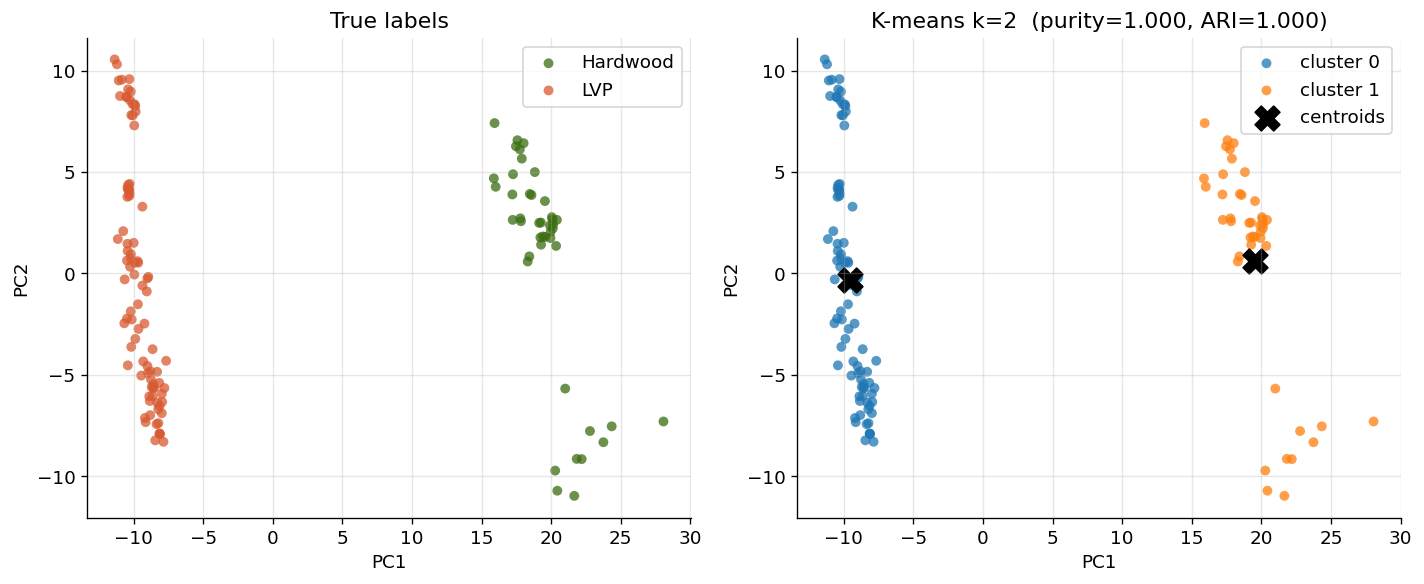

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
TYPE_COLORS = {'LVP': '#d85a30', 'Hardwood': '#3b6d11'}
for t in df['type'].unique():
    m = y_binary == t
    ax[0].scatter(X_pca[m, 0], X_pca[m, 1], s=35, alpha=.75,
                  label=t, color=TYPE_COLORS[t], edgecolor='none')
ax[0].set(title='True labels', xlabel='PC1', ylabel='PC2'); ax[0].legend()
for c in np.unique(clusters_2):
    m = clusters_2 == c
    ax[1].scatter(X_pca[m, 0], X_pca[m, 1], s=35, alpha=.75,
                  label=f'cluster {c}', edgecolor='none')
ax[1].scatter(*pca.transform(km2.cluster_centers_).T, marker='X', s=220,
              c='black', label='centroids')
ax[1].set(title=f'K-means k=2  (purity={scores_2["purity"]:.3f}, ARI={scores_2["ARI"]:.3f})',
          xlabel='PC1', ylabel='PC2'); ax[1].legend()
plt.tight_layout()
plt.savefig('clustering_pca_k2.png', bbox_inches='tight', dpi=120)
plt.show()

## 7. Experiment B — ask for 9 groups (expecting the 9 product classes)

Now the hard case. Three of the nine classes are vinyl that differ *only* in wear-layer
thickness (6 vs 12 vs 22 mil). Thickness is a physical dimension, not a change in chemistry —
the fingerprints look nearly identical. So we should **expect** clustering to struggle here and
lump those together, scoring well below the supervised ~96%.

**What to look for:** ARI noticeably below 1.0, and a heatmap where the vinyl tiers blur into
shared clusters while the chemically-distinct wood species fare better. This is the key teaching
moment — clustering finds *chemical* groupings, not whatever labels we happen to care about.

In [11]:
km9 = KMeans(n_clusters=9, n_init=20, random_state=RANDOM_STATE)
clusters_9 = km9.fit_predict(X_scaled)

scores_9, cm_9 = cluster_scores(y_9, clusters_9)
print('k=9 vs 9 true classes:')
for kk, vv in scores_9.items():
    print(f'  {kk:13s}: {vv:.3f}')

k=9 vs 9 true classes:
  ARI          : 0.700
  homogeneity  : 0.851
  completeness : 0.790
  v_measure    : 0.819
  purity       : 0.843


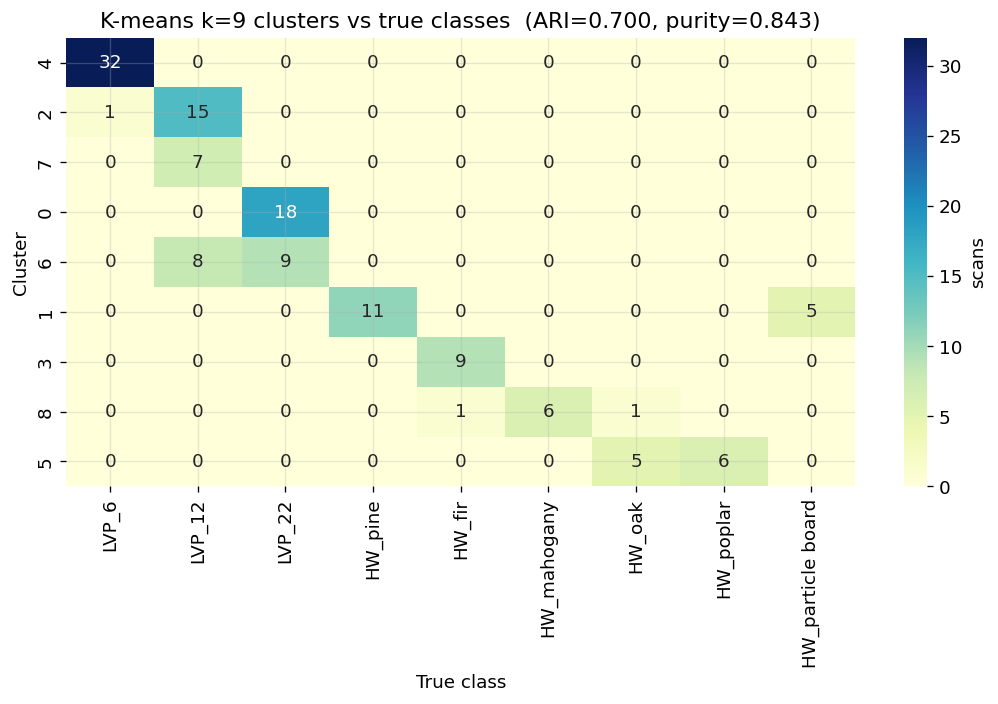

In [12]:
# order rows so each cluster's majority class sits on the diagonal where possible
cm9 = cm_9.copy()
col_order = cm9.sum().sort_values(ascending=False).index
cm9 = cm9[col_order]
row_order = cm9.idxmax(axis=1).map({c: i for i, c in enumerate(col_order)}).sort_values().index
cm9 = cm9.loc[row_order]

plt.figure(figsize=(9, 6))
sns.heatmap(cm9, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'scans'})
plt.title(f'K-means k=9 clusters vs true classes  (ARI={scores_9["ARI"]:.3f}, '
          f'purity={scores_9["purity"]:.3f})')
plt.xlabel('True class'); plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('clustering_pca_k9.png', bbox_inches='tight', dpi=120)
plt.show()

*The same scans, now coloured by their k=9 cluster. Overlapping colours = classes the algorithm couldn't tell apart.*

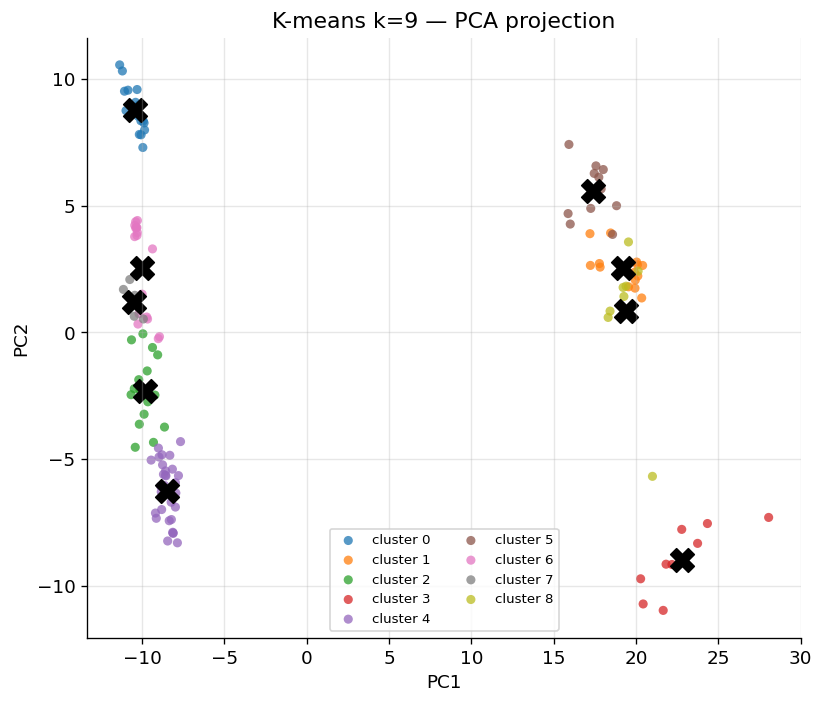

In [13]:
# PCA scatter coloured by k=9 cluster assignment
plt.figure(figsize=(7, 6))
for c in np.unique(clusters_9):
    m = clusters_9 == c
    plt.scatter(X_pca[m, 0], X_pca[m, 1], s=30, alpha=.75,
                label=f'cluster {c}', edgecolor='none')
plt.scatter(*pca.transform(km9.cluster_centers_).T, marker='X', s=200, c='black')
plt.title('K-means k=9 — PCA projection'); plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## 8. Experiment C — wood scans only, ask for 6 groups (expecting species)

Here we throw away the vinyl scans and ask whether the six wood species form six natural groups.
Species with similar make-up (e.g. pine and fir, both softwoods) may blur together, while
distinctive ones should stand on their own.

**What to look for:** moderate purity/ARI, and a heatmap showing which species are cleanly
isolated versus which get confused with each other.

In [14]:
X_wood_scaled = StandardScaler().fit_transform(X_wood)
km6 = KMeans(n_clusters=6, n_init=20, random_state=RANDOM_STATE)
clusters_6 = km6.fit_predict(X_wood_scaled)

scores_6, cm_6 = cluster_scores(y_wood, clusters_6)
print('k=6 vs 6 wood species:')
for kk, vv in scores_6.items():
    print(f'  {kk:13s}: {vv:.3f}')
print()
print(cm_6)

k=6 vs 6 wood species:
  ARI          : 0.713
  homogeneity  : 0.808
  completeness : 0.836
  v_measure    : 0.822
  purity       : 0.841

label    fir  mahogany  oak  particle board  pine  poplar
cluster                                                  
0          7         0    0               0     0       0
1          1         6    3               0     0       0
2          0         0    3               0     0       6
3          2         0    0               0     0       0
4          0         0    0               0    11       0
5          0         0    0               5     0       0


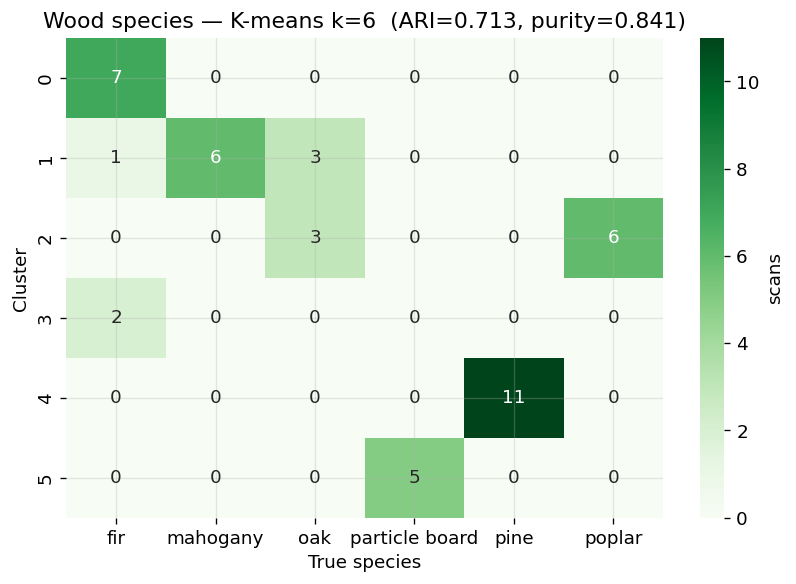

In [15]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm_6, annot=True, fmt='d', cmap='Greens', cbar_kws={'label': 'scans'})
plt.title(f'Wood species — K-means k=6  (ARI={scores_6["ARI"]:.3f}, '
          f'purity={scores_6["purity"]:.3f})')
plt.xlabel('True species'); plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

## 9. A second opinion — hierarchical clustering

K-means makes you commit to a number of groups up front. **Hierarchical clustering** instead
builds a **family tree (dendrogram)**: start with every scan alone, then repeatedly merge the two
closest groups until everything is joined. ("Ward linkage" just means: at each step, merge the
pair that keeps groups as tight as possible.)

The beauty is you can *read the tree*: the **height** at which two scans join tells you how
different they are. The very first, highest split should be the biggest divide in the data — we
expect that to be vinyl-vs-hardwood. We then "cut" the tree at 2 and at 9 groups and check it
agrees with k-means.

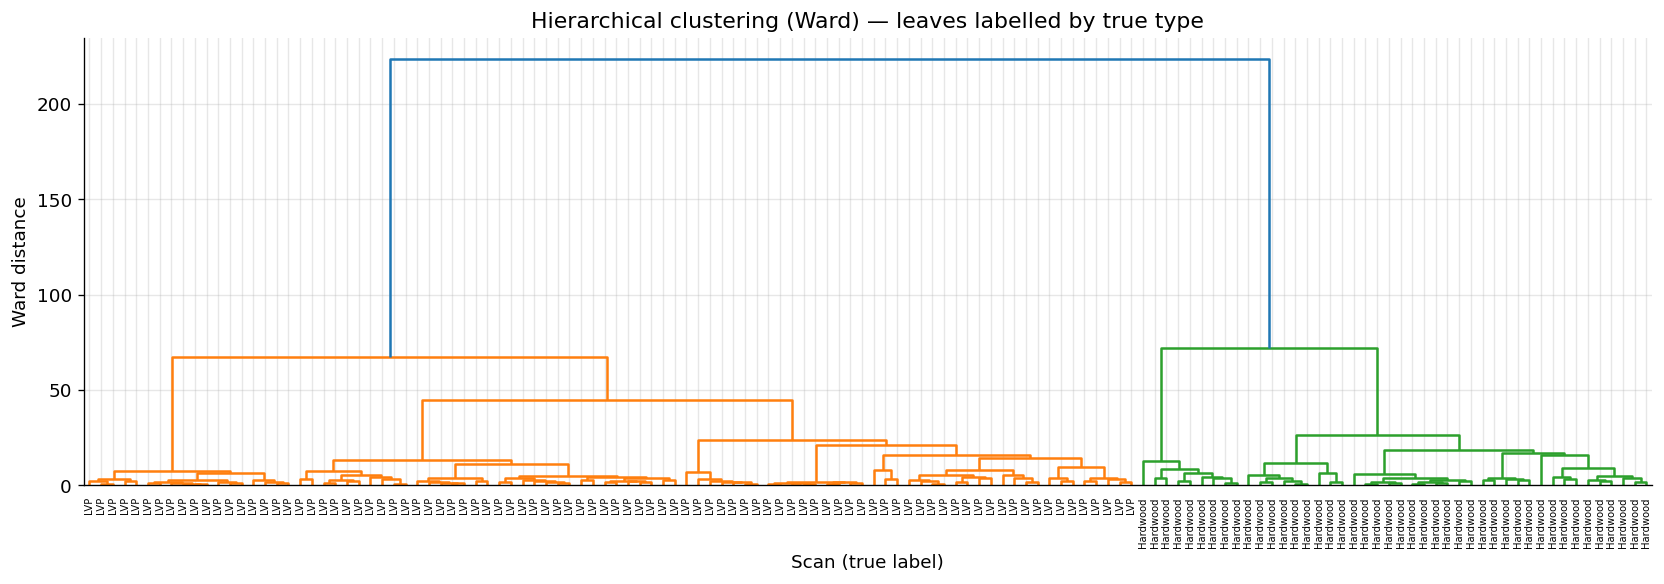

In [16]:
Z = linkage(X_scaled, method='ward')

# colour leaves by true type to read the dendrogram
type_code = (y_binary == 'Hardwood').astype(int)
plt.figure(figsize=(14, 5))
dendrogram(Z, labels=y_binary, leaf_font_size=6, color_threshold=0.7 * Z[:, 2].max())
plt.title('Hierarchical clustering (Ward) — leaves labelled by true type')
plt.xlabel('Scan (true label)'); plt.ylabel('Ward distance')
plt.tight_layout()
plt.savefig('clustering_dendrogram.png', bbox_inches='tight', dpi=120)
plt.show()

In [17]:
hc2 = fcluster(Z, t=2, criterion='maxclust')
hc9 = fcluster(Z, t=9, criterion='maxclust')

hc2_scores, _ = cluster_scores(y_binary, hc2)
hc9_scores, _ = cluster_scores(y_9, hc9)
print('Hierarchical k=2 vs vinyl/HW :', {k: round(v, 3) for k, v in hc2_scores.items()})
print('Hierarchical k=9 vs 9-class  :', {k: round(v, 3) for k, v in hc9_scores.items()})

Hierarchical k=2 vs vinyl/HW : {'ARI': 1.0, 'homogeneity': 1.0, 'completeness': 1.0, 'v_measure': 1.0, 'purity': np.float64(1.0)}
Hierarchical k=9 vs 9-class  : {'ARI': 0.762, 'homogeneity': 0.874, 'completeness': 0.821, 'v_measure': 0.847, 'purity': np.float64(0.896)}


## 10. Putting all the scores side by side

One table collecting every experiment, so we can compare methods (k-means vs hierarchical) and
targets (2 / 9 / 6 groups) at a glance. Read `purity` and `ARI` as the headline numbers:
close to 1.0 = the unsupervised groups matched the real labels.

In [18]:
summary = pd.DataFrame([
    {'Method': 'K-means',      'k': 2, 'Target': 'vinyl/HW',     **scores_2},
    {'Method': 'Hierarchical', 'k': 2, 'Target': 'vinyl/HW',     **hc2_scores},
    {'Method': 'K-means',      'k': 9, 'Target': '9-class',      **scores_9},
    {'Method': 'Hierarchical', 'k': 9, 'Target': '9-class',      **hc9_scores},
    {'Method': 'K-means',      'k': 6, 'Target': 'wood species', **scores_6},
])
for c in ['ARI', 'homogeneity', 'completeness', 'v_measure', 'purity']:
    summary[c] = summary[c].round(3)
summary

,Method,k,Target,ARI,homogeneity,completeness,v_measure,purity
0,K-means,2,vinyl/HW,1.000,1.000,1.000,1.000,1.000
1,Hierarchical,2,vinyl/HW,1.000,1.000,1.000,1.000,1.000
2,K-means,9,9-class,0.700,0.851,0.790,0.819,0.843
3,Hierarchical,9,9-class,0.762,0.874,0.821,0.847,0.896
4,K-means,6,wood species,0.713,0.808,0.836,0.822,0.841


## What did we learn?

**The headline:** unsupervised clustering rediscovered the *big* structure in the data for free,
but it cannot recover distinctions that aren't chemical.

- **Two groups = vinyl vs hardwood: essentially perfect** (purity and ARI ≈ 1.0). All three
  diagnostics also pointed to 2 as the most natural number of groups. This matches intuition:
  plastic and wood are chemically worlds apart, and the earlier PCA already showed one axis
  carrying 93% of the variation along exactly this divide.

- **Nine groups did *not* cleanly recover the nine product classes.** The reason is the teaching
  point of this whole notebook: the three vinyl tiers differ only in *wear-layer thickness*, not
  chemistry, so their fingerprints look the same and clustering merges them. Wear-layer thickness
  is something you can only learn if you're *told* it (supervised) — there's no chemical signal
  for an unsupervised method to latch onto. That's why ARI lands well under the supervised ~96%.

- **Six groups on the wood-only scans gave partial species separation.** Chemically distinctive
  species cluster on their own; similar ones (e.g. pine/fir) tend to share a cluster.

- **Hierarchical clustering told the same story.** Its top-most split *is* the vinyl/hardwood
  divide, and its 2- and 9-group cuts score similarly to k-means — independent confirmation, not
  a fluke of one algorithm.

**Practical takeaway.** If your goal is just "vinyl or wood?", you don't even need labelled
training data — the groups fall out on their own. But for fine distinctions like wear-layer
thickness, you need a *supervised* model, because the information simply isn't there for an
unsupervised method to find.

**Saved figures:** `clustering_elbow.png` (how-many-groups diagnostics), `clustering_pca_k2.png`
(the clean 2-group split), `clustering_pca_k9.png` (9-group confusion heatmap),
`clustering_dendrogram.png` (the family tree).